# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
full_name = 'Єдинець Євген'
student_group = 'ШІ-31'
variant = 6
assert full_name and student_group and variant, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'


In [2]:

flux_options = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

pair_options = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

aggregate_options = ['середнє', 'максимум', 'медіана', 'мінімум']

question_options = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

variant_number = int(variant)
assignment = {
    'ваш потік':                      flux_options[(variant_number * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(pair_options[(variant_number * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        aggregate_options[(variant_number * 5 + 1) % 4],
    'ваше додаткове питання':         question_options[(variant_number * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (full_name, student_group, variant_number))
print('=' * 78)
for key, value in assignment.items():
    print('%-28s %s' % (key + ':', value))


ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Єдинець Євген, ШІ-31, варіант 6
ваш потік:                   P>30
ваша пара для графіка 3:     густина вітру та потік P>1
ваш агрегат для етапу 4:     мінімум
ваше додаткове питання:      У яку добу середнє значення вашого потоку було найбільшим? А найменшим?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})
input_file = '20171129_FINAL_FINAL.xlsx'
flux_columns = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
proton_units = 'протонів/(см²·с·ср)'


---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
df = pd.read_excel(input_file, sheet_name='Sheet1')
display(df.head(10))
print('Типи даних:')
print(df.dtypes)


,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
5,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >30 = Particles at >30 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Типи даних:
Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     objec

**Відповідь 1.1.** При звичайному `read_excel()` pandas помилково взяв перший рядок зі службовими URL за заголовки стовпців. Тому з’явилися назви `Unnamed`, а числові вимірювання разом зі службовими рядками отримали тип `object`. Аркуш містить три різні таблиці, розташовані поруч; їх потрібно читати без спільного заголовка та розділяти.


### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
RAW = pd.read_excel(input_file, sheet_name='Sheet1', header=None)
print('Розмір таблиці:', RAW.shape)
display(RAW.head(30))


Розмір таблиці: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
nonmissing_counts = RAW.notna().sum()
print('Кількість заповнених клітинок:')
print(nonmissing_counts)


Кількість заповнених клітинок:
0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3.** У файлі три таблиці, що відокремлені порожніми стовпцями: A — Excel B–O (індекси pandas 1–14), B — Q–T (16–19), C — Y–AF (24–31). У таблиці A приблизно 7200 заповнених клітинок на стовпець, у B близько 25, у C близько 601; точні числа включають службові написи, тому не дорівнюють кількості вимірювань.


### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
for table_name, r, cols in [('A', slice(0, 26), slice(1, 15)),
                       ('B', slice(13, 27), slice(16, 20)),
                       ('C', slice(0, 27), slice(24, 32))]:
    print('ТАБЛИЦЯ', table_name)
    display(RAW.iloc[r, cols])


ТАБЛИЦЯ A


,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


ТАБЛИЦЯ B


,16,17,18,19
13,ftp://ftp.swpc.noaa.gov/pub/indices/old_indice...,NaN,NaN,NaN
14,NaN,NaN,NaN,NaN
15,Product: Daily Solar Data quar_DSD.txt,NaN,NaN,NaN
16,:Issued: 0825 UT 04 Oct 2017,NaN,NaN,NaN
17,#,NaN,NaN,NaN
18,"# Prepared by the U.S. Dept. of Commerce, NOA...",NaN,NaN,NaN
19,# Please send comments and suggestions to SWP...,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN
21,NaN,NaN,NaN,NaN
22,NaN,NaN,NaN,NaN


ТАБЛИЦЯ C


,24,25,26,27,28,29,30,31
0,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Відповідь 1.4.**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | NOAA SWPC, супутник GOES-15 | Протони: протонів/(см²·с·ср); електрони: електронів/(см²·с·ср) |
| B | NOAA SWPC, добовий набір *Daily Solar Data* (`quar_DSD.txt`) | F10.7 — sfu (стандартні сонячні одиниці радіопотоку; у виведених службових рядках одиницю явно не наведено) |
| C | SOHO CELIAS Proton Monitor | Швидкість — км/с; густина — протонів/см³ |

У службовому описі A `-1.00e+05` позначає відсутнє вимірювання; цей запис не можна вважати реальним потоком.


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
A = RAW.iloc[26:7226, 1:15].copy()
A.columns = ['year', 'month', 'day', 'hhmm', 'julian_day', 'seconds',
             'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
A = A.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)
B = RAW.iloc[27:52, 16:20].copy()
B.columns = ['year', 'month', 'day', 'F10.7']
B = B.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)
C = RAW.iloc[27:628, 26:32].copy()
C.columns = ['year', 'month', 'day', 'hour', 'speed', 'density']
C = C.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)
for table_name, table in [('A', A), ('B', B), ('C', C)]:
    print(f'Таблиця {table_name}: {table.shape}')
    display(table.head())


Таблиця A: (7200, 14)


,year,month,day,hhmm,julian_day,seconds,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0
0,2017,8,28,0,57993,0,12.00,0.260,0.180,0.1140,0.1040,0.0793,23600.0,1180.0
1,2017,8,28,5,57993,300,19.40,0.690,0.314,0.1120,0.0612,0.0251,23100.0,1160.0
2,2017,8,28,10,57993,600,8.48,0.168,0.130,0.0717,0.0614,0.0304,22200.0,1090.0
3,2017,8,28,15,57993,900,15.40,0.566,0.198,0.0926,0.0568,0.0251,20400.0,997.0
4,2017,8,28,20,57993,1200,6.41,0.156,0.118,0.0597,0.0494,0.0251,18500.0,875.0


Таблиця B: (25, 4)


,year,month,day,F10.7
0,2017,8,28,82
1,2017,8,29,84
2,2017,8,30,87
3,2017,8,31,92
4,2017,9,1,93


Таблиця C: (601, 6)


,year,month,day,hour,speed,density
0,17,8,28,0,285,3.0
1,17,8,28,1,305,3.4
2,17,8,28,2,309,1.7
3,17,8,28,3,304,2.0
4,17,8,28,4,302,2.3


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
A = A.assign(ts=pd.to_datetime({
    'year': A['year'],
    'month': A['month'],
    'day': A['day'],
    'hour': A['hhmm'] // 100,
    'minute': A['hhmm'] % 100
}))
B = B.assign(ts=pd.to_datetime({
    'year': B['year'],
    'month': B['month'],
    'day': B['day']
}))
C = C.assign(ts=pd.to_datetime({
    'year': C['year'] + 2000,
    'month': C['month'],
    'day': C['day'],
    'hour': C['hour']
}))
for table_name, table in [('A', A), ('B', B), ('C', C)]:
    print(f'{table_name}: від {table["ts"].min()} до {table["ts"].max()}')


A: від 2017-08-28 00:00:00 до 2017-09-21 23:55:00
B: від 2017-08-28 00:00:00 до 2017-09-21 00:00:00
C: від 2017-08-28 00:00:00 до 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for table_name, table in [('A', A), ('B', B), ('C', C)]:
    years = pd.to_datetime(table['ts']).dt.year
    assert years.min() == 2017 and years.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % table_name
print('Етап 2 пройдено')


Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
for table_name, table in [('A', A), ('B', B), ('C', C)]:
    print()
    print(f'ТАБЛИЦЯ {table_name}; розмір {table.shape}')
    print('Типи стовпців:')
    print(table.dtypes)
    print('Пропуски:')
    print(table.isna().sum())
    print('Повні дублікати:', table.duplicated().sum())
    display(table.describe(include='all'))



ТАБЛИЦЯ A; розмір (7200, 15)
Типи стовпців:
year                   int64
month                  int64
day                    int64
hhmm                   int64
julian_day             int64
seconds                int64
P>1                  float64
P>5                  float64
P>10                 float64
P>30                 float64
P>50                 float64
P>100                float64
E>0.8                float64
E>2.0                float64
ts            datetime64[ns]
dtype: object
Пропуски:
year          0
month         0
day           0
hhmm          0
julian_day    0
seconds       0
P>1           3
P>5           3
P>10          3
P>30          3
P>50          3
P>100         3
E>0.8         3
E>2.0         3
ts            0
dtype: int64
Повні дублікати: 0


,year,month,day,hhmm,julian_day,seconds,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN



ТАБЛИЦЯ B; розмір (25, 5)
Типи стовпців:
year              int64
month             int64
day               int64
F10.7             int64
ts       datetime64[ns]
dtype: object
Пропуски:
year     0
month    0
day      0
F10.7    0
ts       0
dtype: int64
Повні дублікати: 0


,year,month,day,F10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN



ТАБЛИЦЯ C; розмір (601, 7)
Типи стовпців:
year                int64
month               int64
day                 int64
hour                int64
speed               int64
density           float64
ts         datetime64[ns]
dtype: object
Пропуски:
year       0
month      0
day        0
hour       0
speed      0
density    0
ts         0
dtype: int64
Повні дублікати: 0


,year,month,day,hour,speed,density,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,17.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,17.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,17.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,17.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,17.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
stats_before = C[['speed', 'density']].agg(['mean', 'min'])
negative_counts = (C[['speed', 'density']] < 0).sum()
print('Від’ємні значення у C:')
print(negative_counts)
print('Виявлені значення:')
for column in ['speed', 'density']:
    print(column, C.loc[C[column] < 0, column].value_counts().to_dict())
C = C.assign(
    speed=C['speed'].mask(C['speed'] < 0),
    density=C['density'].mask(C['density'] < 0)
)
stats_after = C[['speed', 'density']].agg(['mean', 'min'])
statistics_comparison = pd.concat({'до очищення': stats_before, 'після очищення': stats_after})
display(statistics_comparison)
A = A.replace({column: {-100000: np.nan} for column in flux_columns})
print('Позначки -100000 у потоках A після очищення:', int(A[flux_columns].eq(-100000).sum().sum()))


Від’ємні значення у C:
speed      8
density    8
dtype: int64
Виявлені значення:
speed {-1: 8}
density {-1.0: 8}


speed   density
до очищення    mean  506.547421  2.907654
               min    -1.000000 -1.000000
після очищення mean  513.394604  2.960371
               min   277.000000  0.100000

Позначки -100000 у потоках A після очищення: 0


**Відповідь 3.2.** У C є **8** від’ємних значень `speed` та **8** значень `density` (значення `-1` в одних і тих самих восьми годинах 04.09.2017). Фізично ці величини не можуть бути від’ємними, отже `-1` слід трактувати як відсутній вимір і замінити на `NaN`; у доступному службовому описі C значення `-1` окремо не розшифроване, висновок зроблено за його повторенням і фізичним змістом. Швидкість: середнє **506.547 → 513.395 км/с**, мінімум **−1 → 277 км/с**. Густина: середнє **2.908 → 2.960 протонів/см³**, мінімум **−1 → 0.1 протонів/см³**. Неочищені позначки відсутніх вимірювань занижували середні значення. У A службова позначка пропуску — `-100000`, проте у вибраних 7200 рядках у потоках вона не трапляється; натомість є по три початкові пропуски на кожен потік.


### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
date_code_columns = ['year', 'month', 'day', 'hhmm', 'julian_day', 'seconds']
display(A[date_code_columns].describe().loc[['mean', 'std']])


,year,month,day,hhmm,julian_day,seconds
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498


**Відповідь 3.3.** Середні для `year`, `month`, `day`, `hhmm`, `julian_day` і `seconds` не характеризують інтенсивність випромінювання: це частини дати, номери днів і коди часу, а не фізичні вимірювання. Наприклад, середнє арифметичне числа `1330` (13:30) і `1430` (14:30) не є надійним способом обчислити середній час. Для дослідження дат слід використовувати `ts` та відповідні часові операції.


---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
A_hour = A.set_index('ts')[flux_columns].resample('h').agg(['mean', 'max'])
A_hour.columns = [f'{selected_flux}_{aggregate_name}' for selected_flux, aggregate_name in A_hour.columns]
A_hour = A_hour.reset_index()
print('Погодинна таблиця A:', A_hour.shape)
display(A_hour.head())


Погодинна таблиця A: (600, 17)


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

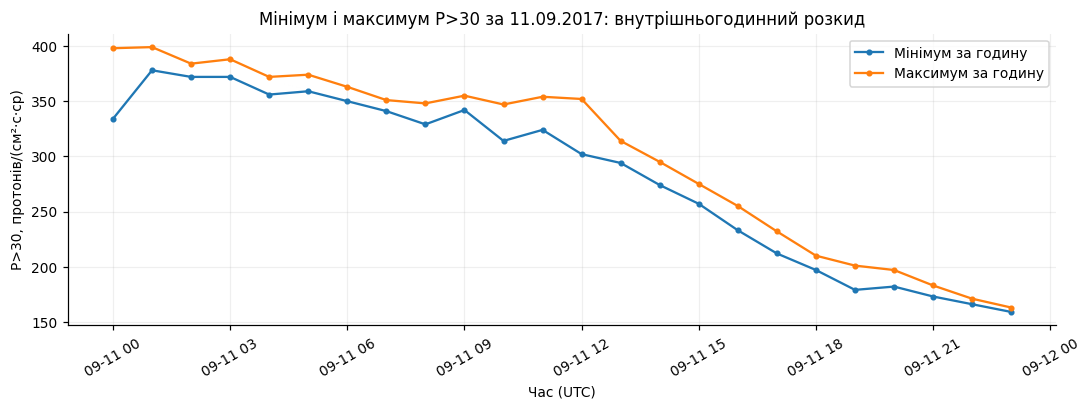

Найбільша різниця між максимумом і мінімумом за годину: 64.0


In [15]:
selected_flux = assignment['ваш потік']
selected_aggregate = assignment['ваш агрегат для етапу 4']
aggregate_functions = {'середнє': 'mean', 'максимум': 'max', 'медіана': 'median', 'мінімум': 'min'}
selected_day = A.loc[A[selected_flux].idxmax(), 'ts'].normalize()
day_flux = A.set_index('ts').loc[selected_day:selected_day + pd.Timedelta(days=1) - pd.Timedelta(minutes=1), selected_flux]
hourly_curves = day_flux.resample('h').agg([aggregate_functions[selected_aggregate], 'max'])
hourly_curves.columns = [selected_aggregate, 'максимум']
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(hourly_curves.index, hourly_curves[selected_aggregate], marker='o', ms=3, label='Мінімум за годину')
ax.plot(hourly_curves.index, hourly_curves['максимум'], marker='o', ms=3, label='Максимум за годину')
ax.set(title=f'Мінімум і максимум P>30 за {selected_day:%d.%m.%Y}: внутрішньогодинний розкид',
       xlabel='Час (UTC)', ylabel=f'P>30, {proton_units}')
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()
print('Найбільша різниця між максимумом і мінімумом за годину:', round((hourly_curves['максимум'] - hourly_curves[selected_aggregate]).max(), 3))


**Відповідь 4.2.** Для доби **11.09.2017** обрано агрегати «мінімум» (мій варіант) і «максимум». Максимум показує короткочасні піки всередині години, а мінімум — найнижчий зафіксований у цю годину рівень. Найбільша різниця між ними досягає **64.000 протонів/(см²·с·ср)**. Відмінність важлива, коли 5-хвилинні вимірювання сильно змінюються всередині однієї години: мінімум приховує короткі сплески, максимум підкреслює їх.


### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
start_time = B['ts'].min()
end_time = B['ts'].max() + pd.Timedelta(hours=23)
daily_hour_index = pd.date_range(start_time, end_time, freq='h')
B_hour = (B.set_index('ts')[['F10.7']].reindex(daily_hour_index).ffill()
          .rename_axis('ts').reset_index())
C_hour = C[['ts', 'speed', 'density']].copy()
hourly_tables = [table.set_index('ts') for table in (A_hour, C_hour, B_hour)]
M_inner = pd.concat(hourly_tables, axis=1, join='inner').sort_index().rename_axis('ts').reset_index()
M_outer = pd.concat(hourly_tables, axis=1, join='outer').sort_index().rename_axis('ts').reset_index()
M = M_outer.copy()
print('B після розгортання до годин:', B_hour.shape)
print('inner:', M_inner.shape, 'outer:', M_outer.shape)
print('M, розмір:', M.shape)
print('Рядки з принаймні одним пропуском:')
display(M.loc[M.isna().any(axis=1)])

B після розгортання до годин: (600, 2)
inner: (600, 20) outer: (601, 20)
M, розмір: (601, 20)
Рядки з принаймні одним пропуском:


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,speed,density,F10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0
600,2017-09-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,381.0,1.0,NaN


**Відповідь 4.3.** Добові значення B поширено на всі 24 години кожної доби, A зведено з 5 хвилин до години, C має погодинний крок. `inner` дає **600** спільних годин, `outer` — **601**: C додатково містить **22.09.2017 00:00**, коли у A і B вже немає даних. Обрано `outer`, щоб не втратити наявне спостереження вітру, а пропуски на краю періоду явно позначити `NaN`. Стовпці `speed` і `density` також мають по 8 пропусків після заміни некоректного `-1`.


### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
group_conditions = [
    M['P>10_max'] < 10,
    M['P>10_max'].between(10, 1000, inclusive='left'),
    M['P>10_max'] >= 1000
]
M = M.assign(**{'група': np.select(group_conditions, ['тиха', 'активна', 'дуже активна'], default=None)})
print('Кількість годин у кожній групі:')
print(M['група'].value_counts(dropna=False))


Кількість годин у кожній групі:
група
тиха            411
активна         171
дуже активна     18
None              1
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')


Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

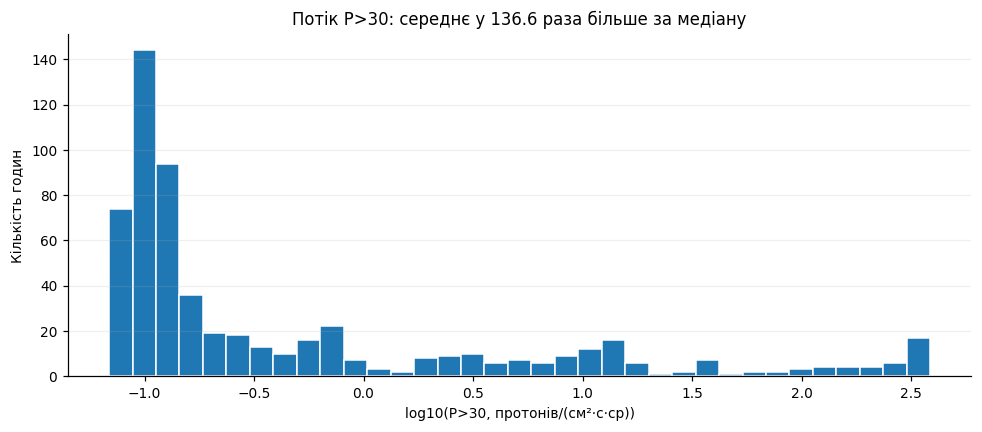

Середнє: 18.831273; медіана: 0.137825; годин із додатним потоком: 600


In [19]:
flux_values = M[f'{selected_flux}_mean'].dropna()
flux_mean = flux_values.mean()
flux_median = flux_values.median()
positive_flux = flux_values[flux_values > 0]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log10(positive_flux), bins=35, edgecolor='white')
ax.set(title=f'Потік {selected_flux}: середнє у {flux_mean/flux_median:.1f} раза більше за медіану',
       xlabel=f'log10({selected_flux}, {proton_units})', ylabel='Кількість годин')
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()
print(f'Середнє: {flux_mean:.6f}; медіана: {flux_median:.6f}; годин із додатним потоком: {len(positive_flux)}')


**Висновок:** погодинне середнє P>30 становить **18.831**, а медіана лише **0.137825 протонів/(см²·с·ср)**; середнє приблизно у **136.6 раза** більше, бо порівняно нечисленні години з дуже великим потоком зміщують його вгору, а логарифм робить широкий діапазон значень видимим.


### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

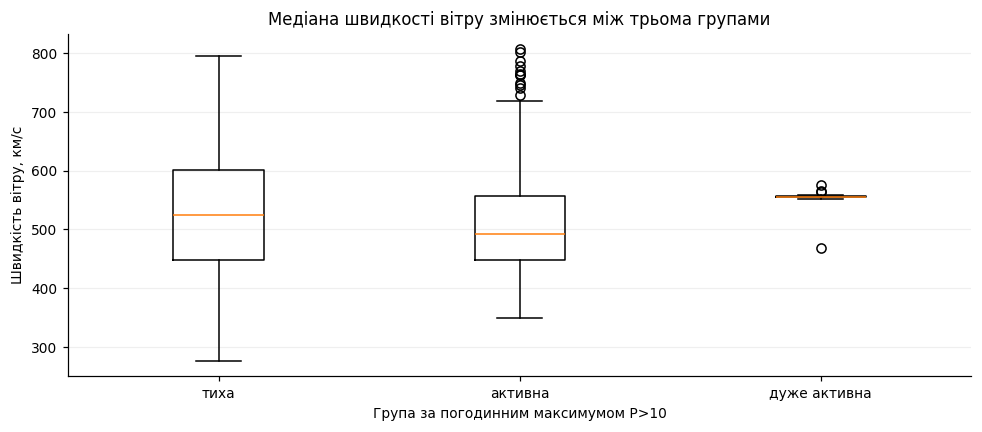

Число валідних швидкостей: [403, 171, 18]
Медіани швидкості (км/с): {'тиха': 524.0, 'активна': 492.0, 'дуже активна': 556.0}


In [20]:
group_names = ['тиха', 'активна', 'дуже активна']
wind_speeds = [M.loc[M['група'] == table_name, 'speed'].dropna() for table_name in group_names]
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(wind_speeds, tick_labels=group_names, showfliers=True)
wind_medians = [values.median() for values in wind_speeds]
ax.set(title='Медіана швидкості вітру змінюється між трьома групами',
       xlabel='Група за погодинним максимумом P>10', ylabel='Швидкість вітру, км/с')
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()
print('Число валідних швидкостей:', [len(x) for x in wind_speeds])
print('Медіани швидкості (км/с):', dict(zip(group_names, wind_medians)))


**Висновок:** медіана швидкості вітру дорівнює **524 км/с** для тихих, **492 км/с** для активних і **556 км/с** для дуже активних годин; розподіли перекриваються, тож самою швидкістю групу протонної активності однозначно визначити не можна.


### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

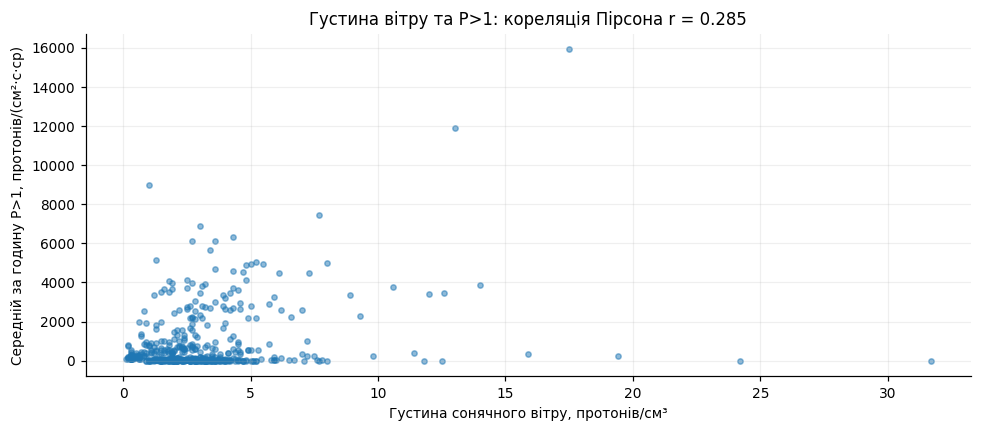

Кількість пар спостережень: 592 кореляція: 0.2853


In [21]:
paired_values = M[['density', 'P>1_mean']].dropna()
correlation = paired_values['density'].corr(paired_values['P>1_mean'])
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(paired_values['density'], paired_values['P>1_mean'], s=12, alpha=0.5)
ax.set(title=f'Густина вітру та P>1: кореляція Пірсона r = {correlation:.3f}',
       xlabel='Густина сонячного вітру, протонів/см³',
       ylabel=f'Середній за годину P>1, {proton_units}')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()
print('Кількість пар спостережень:', len(paired_values), 'кореляція:', round(correlation, 4))


**Висновок:** для **592** годин із наявними обома показниками кореляція Пірсона між густиною вітру та середнім потоком P>1 становить **r = 0.285**: є слабкий додатний лінійний зв’язок у цих спостереженнях, але цей коефіцієнт сам собою не доводить причинного впливу.


### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

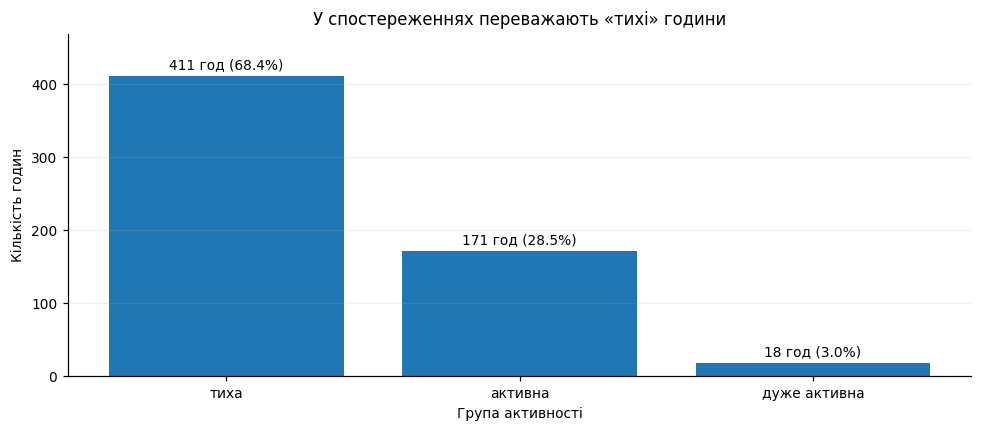

Усього рядків M: 601 годин без визначеної групи: 1


In [22]:
group_counts = M['група'].value_counts().reindex(group_names, fill_value=0)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(group_counts.index, group_counts.values)
ax.bar_label(bars, labels=[f'{count} год ({count/len(M)*100:.1f}%)' for count in group_counts], padding=3)
ax.set_ylim(0, max(group_counts) * 1.14)
ax.set(title='У спостереженнях переважають «тихі» години',
       xlabel='Група активності', ylabel='Кількість годин')
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()
print('Усього рядків M:', len(M), 'годин без визначеної групи:', M['група'].isna().sum())


**Висновок:** із **601** годин **411 (68.4%)** є тихими, **171 (28.5%)** — активними, **18 (3.0%)** — дуже активними; ще **1** година не класифікована через відсутність P>10.


### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

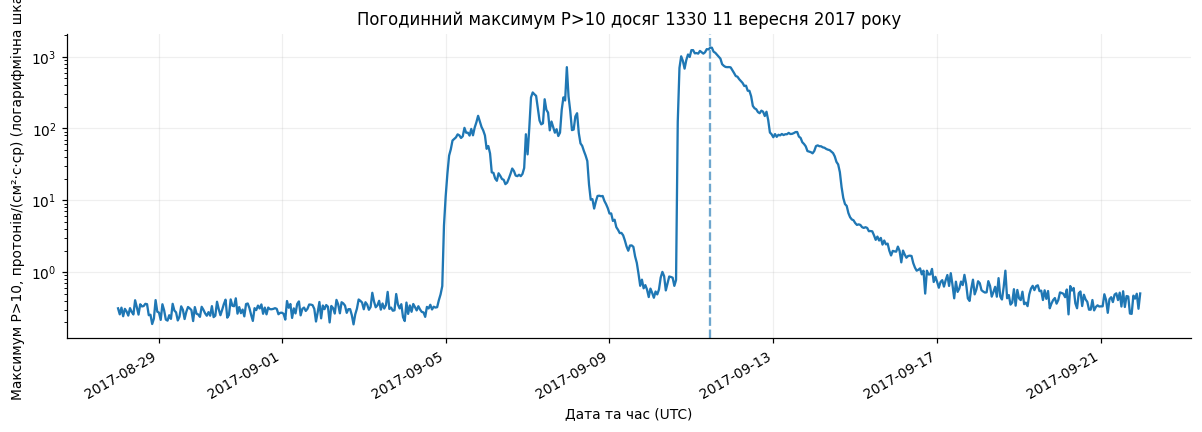

Пік: 2017-09-11 11:00:00 значення: 1330.0


In [23]:
peak_time = M.loc[M['P>10_max'].idxmax(), 'ts']
peak_value = M['P>10_max'].max()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(M['ts'], M['P>10_max'])
ax.set_yscale('log')
ax.axvline(peak_time, linestyle='--', alpha=0.65)
ax.set(title=f'Погодинний максимум P>10 досяг {peak_value:.0f} 11 вересня 2017 року',
       xlabel='Дата та час (UTC)', ylabel=f'Максимум P>10, {proton_units} (логарифмічна шкала)')
ax.grid(alpha=0.2)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()
print('Пік:', peak_time, 'значення:', peak_value)


**Висновок:** погодинний максимум P>10 досяг **1330 протонів/(см²·с·ср)** **11.09.2017 о 11:00 UTC**; логарифмічна вісь дозволяє побачити як цей сплеск, так і значно менші значення в інші дні.


---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

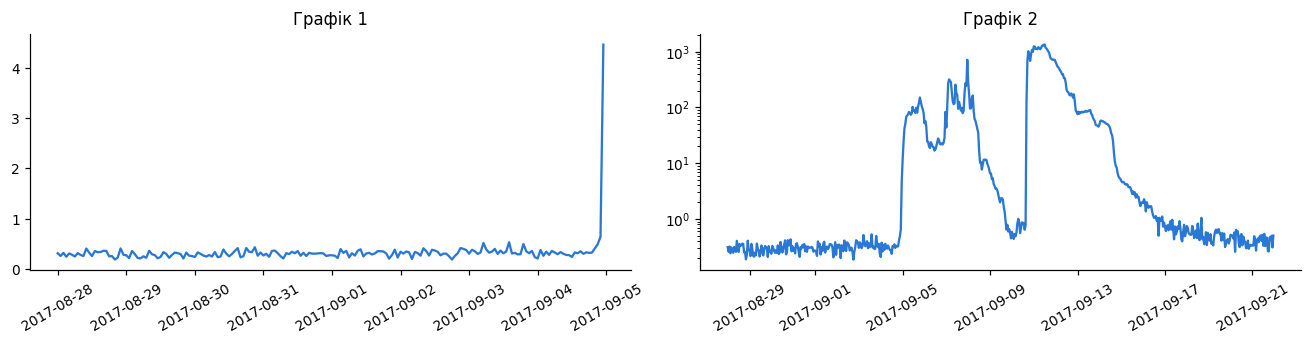

In [24]:
target_column = 'P>10_max'
view_window = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].plot(view_window['ts'], view_window[target_column], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)
ax[1].plot(M['ts'], M[target_column], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()


### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1.**

1. Людина, яка бачить лише перший графік, може вирішити, що протонна активність протягом розглянутих днів залишалася відносно невеликою: найбільший P>10 тут лише **4.46**. Однак перший графік узагалі не показує період після 04.09.2017.
2. Другий графік показує весь період, зокрема сплеск **11.09.2017** до **1330**. Він також показує відносні зміни малих значень завдяки логарифмічній шкалі, яка візуально стискає найбільші величини.
3. Дві відмінності в коді: **(а)** перший графік обмежений часовим вікном 28.08–04.09, другий охоплює всю таблицю M; **(б)** перший використовує звичайну лінійну шкалу Y, другий — логарифмічну.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

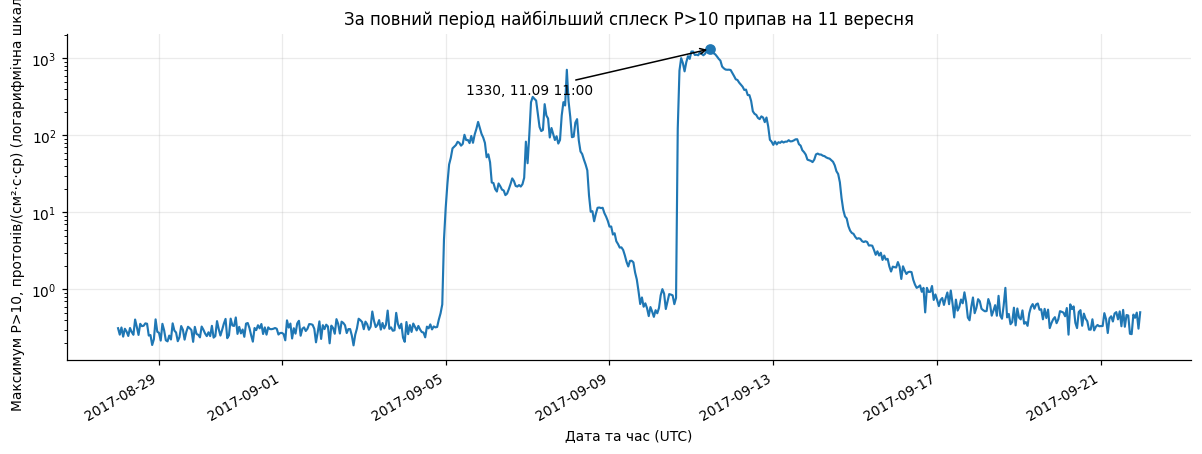

In [25]:
valid_flux_rows = M.dropna(subset=['P>10_max'])
overall_peak_time = valid_flux_rows.loc[valid_flux_rows['P>10_max'].idxmax(), 'ts']
overall_peak_value = valid_flux_rows['P>10_max'].max()
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(valid_flux_rows['ts'], valid_flux_rows['P>10_max'], linewidth=1.4, label='Погодинний максимум P>10')
ax.set_yscale('log')
ax.scatter([overall_peak_time], [overall_peak_value], zorder=3)
ax.annotate(f'{overall_peak_value:.0f}, {overall_peak_time:%d.%m %H:%M}',
            xy=(overall_peak_time, overall_peak_value), xytext=(-160, -30),
            textcoords='offset points', arrowprops={'arrowstyle': '->'})
ax.set(title='За повний період найбільший сплеск P>10 припав на 11 вересня',
       xlabel='Дата та час (UTC)',
       ylabel=f'Максимум P>10, {proton_units} (логарифмічна шкала)')
ax.grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


**Відповідь 6.2.** Я використав увесь доступний період, прямо підписав одиниці та логарифмічну шкалу Y, а найвищий пік додатково позначив його фактичним числом і датою. Такий графік не приховує вересневий сплеск обрізанням діапазону часу й водночас дає побачити відносні зміни меншого потоку; логарифмічна шкала не призначена для порівняння абсолютних різниць за висотою лінії.


---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1.** За гістограмою та розрахунком у графіку 1 середнє P>30 (**18.831**) приблизно у **136.6 раза** вище медіани (**0.137825**): кілька годин великих потоків сильно впливають на середнє. Джерело: етап 5, графік 1.

**Спостереження 2.** У **18** годинах максимум P>10 був не меншим за 1000, тоді як **411** годин мали значення нижче 10; одна година не класифікується через пропуск. Джерело: етап 4, завдання 4.4, та етап 5, графік 4.

**Спостереження 3.** У таблиці C вісім пар значень `−1` збіглися за часом; після заміни їх на `NaN` середня швидкість зросла з **506.547** до **513.395 км/с**. Джерело: етап 3, завдання 3.2.


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:

flux_column = f'{selected_flux}_mean'

daily_means = (
    M.groupby(M['ts'].dt.normalize())[flux_column]
    .mean()
)

highest_day = daily_means.idxmax()
lowest_day = daily_means.idxmin()

highest_value = daily_means.max()
lowest_value = daily_means.min()

print(
    f'Найбільше добове середнє {selected_flux}: '
    f'{highest_day:%Y-%m-%d} — '
    f'{highest_value:.6f} {proton_units}'
)

print(
    f'Найменше добове середнє {selected_flux}: '
    f'{lowest_day:%Y-%m-%d} — '
    f'{lowest_value:.6f} {proton_units}'
)

display(
    daily_means.rename(
        f'{selected_flux}: середнє за добу'
    ).to_frame()
)

Найбільше добове середнє P>30: 2017-09-11 — 292.930556 протонів/(см²·с·ср)
Найменше добове середнє P>30: 2017-09-01 — 0.089734 протонів/(см²·с·ср)


,P>30: середнє за добу
ts,
2017-08-28,0.092297
2017-08-29,0.091266
2017-08-30,0.094493
2017-08-31,0.092415
2017-09-01,0.089734
2017-09-02,0.090684
2017-09-03,0.098962
2017-09-04,0.106562
2017-09-05,0.650576


**Відповідь 7.2 (варіант 6).** Найвище середнє за добу для погодинного потоку P>30 було **11.09.2017 — 292.930556 протонів/(см²·с·ср)**; найнижче — **01.09.2017 — 0.089734 протонів/(см²·с·ср)**. Розрахунок виконано за 25 повними добами, для яких у таблиці M є спостереження P>30; додатковий рядок 22.09.2017 містить лише показники вітру та до середніх не включений.


---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

**Примітка для автора.** Записи про перевірку згенерованого коду й підтвердження можливості пояснити кожен рядок заповнюються тільки після власного перегляду готового ноутбука. Перш ніж здавати роботу, звірте результати, скоригуйте декларацію за фактичними діями, установіть `ПІДТВЕРДЖУЮ = True` лише за умови, що дійсно можете пояснити й змінити код, і повторіть `Restart & Run All`.


In [27]:
ai_tools = 'ChatGPT'
ai_declaration = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення': 'синтаксис',
    'етап 4, об’єднання таблиць': 'код, перевірено',
    'етап 5, побудова графіків': 'код, перевірено',
    'етап 5, формулювання висновків': 'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'код, перевірено',
}

verification_notes = (
    'Під час виконання лабораторної роботи я використовував ChatGPT '
    'для допомоги з написанням коду, пояснення функцій pandas та '
    'побудови графіків. Я розібрав код і перевірив його виконання '
    'у Jupyter Notebook. Перевірив правильність формування часових '
    'міток, кількість рядків у таблицях A (7200), B (25) і C (601), '
    'очищення некоректних значень та об’єднання таблиць у 601 погодинний '
    'запис. Також звірив результати індивідуального завдання: '
    'найбільше добове середнє потоку P>30 спостерігалося '
    '11.09.2017 (292.930556), а найменше - 01.09.2017 (0.089734). '
    'Я переглянув побудовані графіки, розібрав їхні підписи та висновки.'
)
confirmed_understanding = True


In [28]:

allowed_responses = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ai_tools.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
blank_entries = [key for key, value in ai_declaration.items() if not str(value).strip()]
assert not blank_entries, 'Не заповнено пункти декларації: %s' % '; '.join(blank_entries)
invalid_entries = {value for value in ai_declaration.values() if value not in allowed_responses}
assert not invalid_entries, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(invalid_entries))
assert len(verification_notes.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(verification_notes.strip()))
assert confirmed_understanding is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', full_name))
print('%-46s %s' % ('інструменти:', ai_tools))
print('-' * 78)
for key, value in ai_declaration.items():
    print('%-46s %s' % (key + ':', value))
print('-' * 78)
print('перевірено автором:')
print(verification_notes)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')


ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Єдинець Євген
інструменти:                                   ChatGPT
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: код, перевірено
------------------------------------------------------------------------------
перевірено автором:
Під час виконання лабораторної роботи я використовував ChatGPT для допомоги з написанням коду, пояснення функцій pandas та побудови графіків. Я розібрав код і перевірив його виконання у Jupyter Notebook. Перевірив правильність формування часових міток, кількість рядків у таблицях A (7200), B

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('Збережено master_hourly.csv:', M.shape)


Збережено master_hourly.csv: (601, 21)


In [30]:

checks = {
    'ПІБ і варіант заповнено':        bool(full_name) and bool(variant),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ai_tools.strip()) and confirmed_understanding is True,
}
for key, value in checks.items():
    print(('OK   ' if value else 'НЕ ОК') + '  ' + key)

if all(checks.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')


OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
